# 🏡 House Prices Prediction

**Predicting House Prices Using Machine Learning**

---

## 📌 Introduction

Predicting house prices is one of the most common supervised machine learning problems in real estate analytics. The objective of this project is to build and evaluate regression models capable of estimating residential property prices based on their characteristics.

This project follows a complete end-to-end machine learning workflow, including data cleaning, exploratory data analysis (EDA), feature engineering, model training, and model evaluation.

---

## 🎯 Project Objectives

- Explore and understand the dataset.
- Clean and preprocess the data.
- Handle missing values.
- Train multiple regression models.
- Compare model performance.
- Select the best-performing model.

---

## 🤖 Models Used

| Model | Description |
|-------|-------------|
| Linear Regression | Baseline linear model |
| CatBoost Regressor | Gradient boosting with categorical features support |
| XGBoost Regressor | Optimized gradient boosting framework |

---

## 📊 Evaluation Metrics

| Metric | Description |
|--------|-------------|
| R² Score | Coefficient of determination |
| RMSE | Root Mean Squared Error |

---

## 🛠️ Technologies

`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Scikit-learn` · `CatBoost` · `XGBoost` · `Joblib`

---

## 📚 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from xgboost import XGBRegressor
import warnings
import catboost 
from catboost import CatBoostRegressor
warnings.filterwarnings('ignore')

# 📂 Load Dataset


In [2]:
data = pd.read_csv('kc_house_data.csv')

#### 🔍 Understanding the Dataset

In [3]:
pd.set_option('display.max_columns', None)
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
data.shape

(21613, 21)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [6]:
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# 📊 Exploratory Data Analysis (EDA)


### 📈 1. Target Variable Distribution (Price)

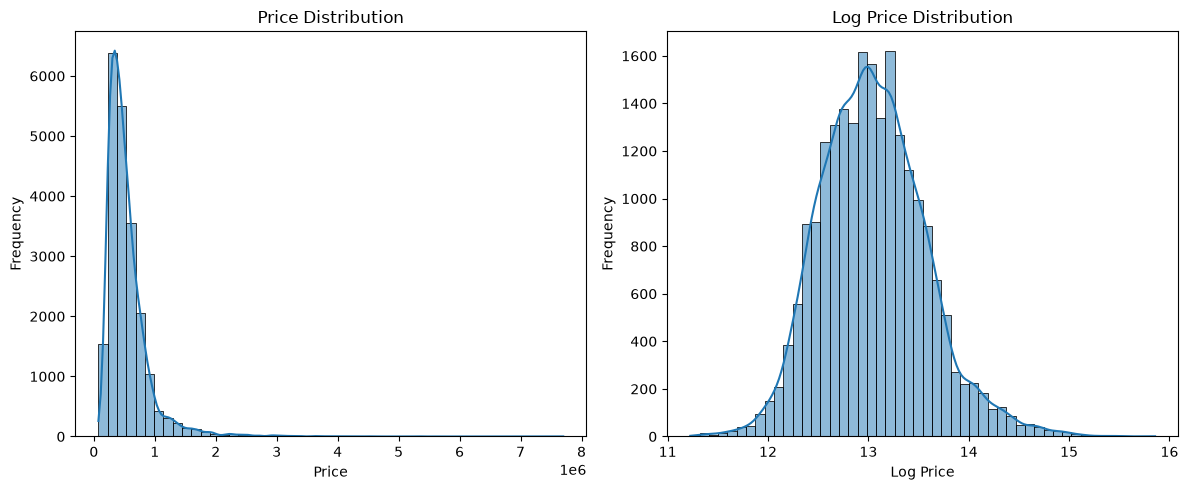

In [7]:
fig , axes = plt.subplots(1,2, figsize=(12,5))
price_log=np.log(data['price'])
sns.histplot(data['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
sns.histplot(price_log, bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log Price Distribution')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [8]:
print("Skewness of Price: ", data['price'].skew())
print("Skewness of Log Price: ", price_log.skew())


Skewness of Price:  4.024069144684714
Skewness of Log Price:  0.4280724755759251


### 🔗 2. Correlation Matrix - Top Features

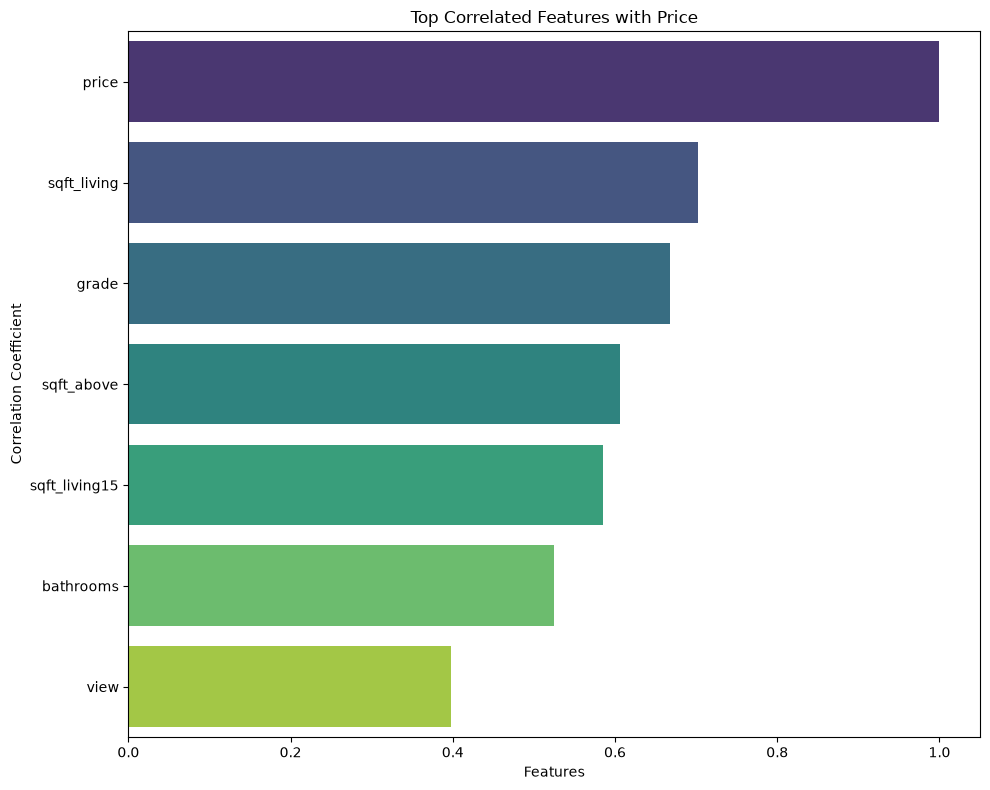

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
Name: price, dtype: float64


In [9]:
corr_matrix = data.corr(numeric_only=True)
top_corr_features = corr_matrix['price'].sort_values(ascending=False).head(7)
plt.figure(figsize=(10,8))
sns.barplot(x=top_corr_features.values, y=top_corr_features.index ,palette='viridis')
plt.title('Top Correlated Features with Price')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.tight_layout()
plt.show()
print(top_corr_features)

### 🌡️ 3. Correlation Heatmap - Top Numeric Features

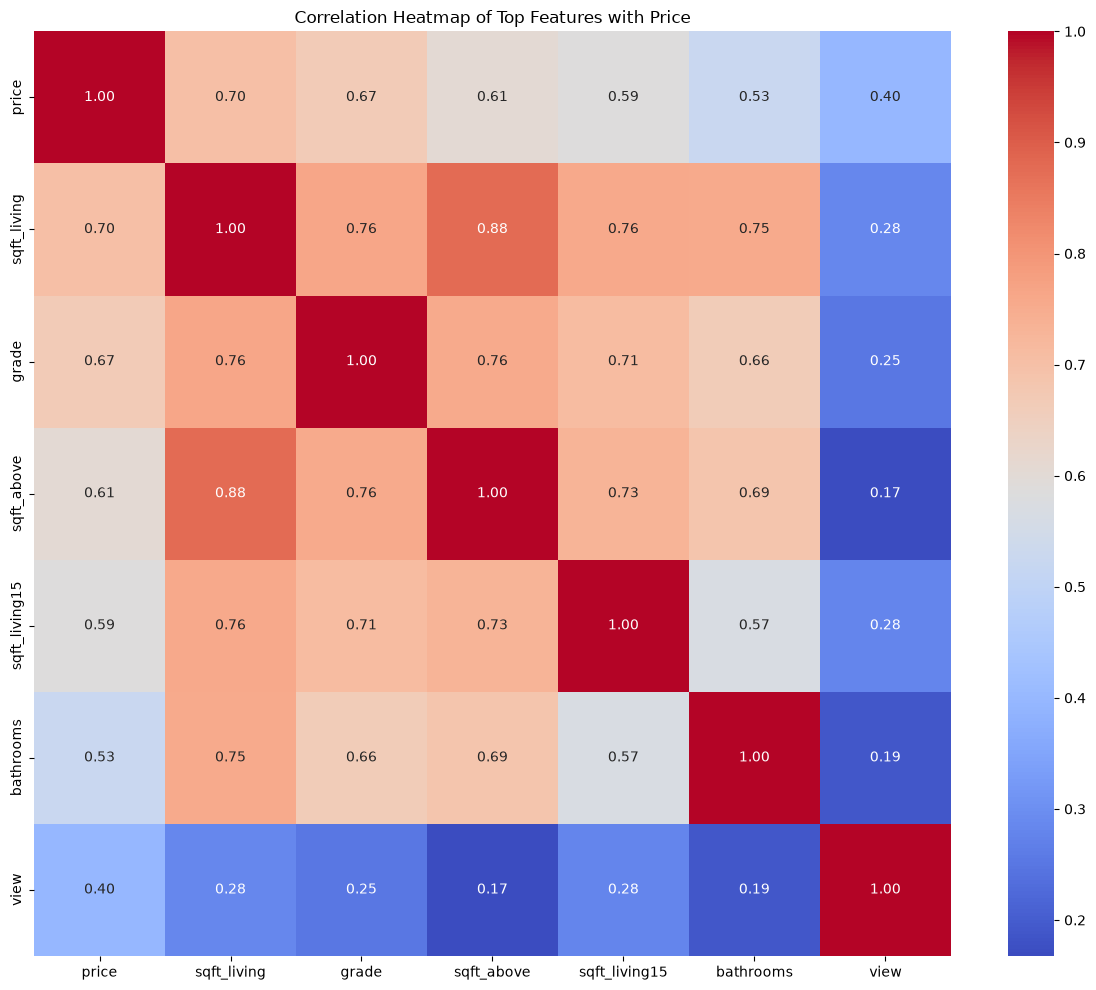

In [10]:
top_corr_features = top_corr_features.index.tolist()
plt.figure(figsize=(12,10))
sns.heatmap(data[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Top Features with Price')
plt.tight_layout()
plt.show()

In [11]:
data[['price','sqft_living','grade','sqft_living15','bathrooms']].info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   sqft_living    21613 non-null  int64  
 2   grade          21613 non-null  int64  
 3   sqft_living15  21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 844.4 KB


### ⚠️ 4. Outlier Removal


In [12]:
outliers_1 = data[(data['sqft_living'] > 8000) & (data['price'] < 1000000)]
outliers_2 = data[(data['sqft_living'] < 500) & (data['price'] > 1000000)]
outliers_3 = data[(data['grade'] >= 11) & (data['price'] < 500000)]
outliers_4 = data[(data['grade'] <= 4) & (data['price'] > 1000000)]
outliers_5 = data[(data['bathrooms'] >= 5) & (data['price'] < 400000)]
outliers_6 = data[(data['sqft_living15'] > 6000) & (data['price'] < 700000)]
all_outliers = pd.concat([outliers_1, outliers_2, outliers_3, outliers_4, outliers_5, outliers_6]).drop_duplicates()

print(f"Total outliers found: {len(all_outliers)}")
print(all_outliers[['sqft_living', 'grade', 'price','bathrooms']])

data = data.drop(all_outliers.index)
print(f"Train shape after removing outliers: {data.shape}")

Total outliers found: 3
       sqft_living  grade     price  bathrooms
19097         3360     11  420000.0       2.50
16803         2860      7  300000.0       5.25
20984         2732      7  343000.0       5.00
Train shape after removing outliers: (21610, 21)


# 🧹Checking for null Values

In [28]:
data.isnull().sum()

id                     0
date                   0
price                  0
bedrooms               0
bathrooms              0
sqft_living            0
sqft_lot               0
floors                 0
waterfront             0
view                   0
condition              0
grade                  0
sqft_above             0
sqft_basement          0
yr_built               0
yr_renovated           0
zipcode                0
lat                    0
long                   0
sqft_living15          0
sqft_lot15             0
bath_per_bedroom       0
basement_ratio         0
grade_sqft             0
floors_sqft            0
living_vs_neighbors    0
lot_vs_neighbors       0
dtype: int64

# ⚙️ Feature Engineering


In [14]:

data['bath_per_bedroom'] = data['bathrooms'] / (data['bedrooms'] + 1e-5)
data['basement_ratio'] = data['sqft_basement'] / (data['sqft_living'] + 1e-5)
data['grade_sqft'] = data['grade'] * data['sqft_living']
data['floors_sqft'] = data['floors'] * data['sqft_living']
data['living_vs_neighbors'] = data['sqft_living'] / (data['sqft_living15'] + 1e-5)
data['lot_vs_neighbors'] = data['sqft_lot'] / (data['sqft_lot15'] + 1e-5)

data = data.replace([np.inf, -np.inf], np.nan)
data = data.fillna(0)

# 🔢 Feature Encoding


In [15]:
x_data=data.drop(['id','date','price'], axis=1)
y_data=np.log1p(data['price'])

In [16]:
x_data_final, x_val, y_data_final, y_val = train_test_split(x_data, y_data, test_size=0.2, random_state=42)
print(x_data_final.shape)
print(x_val.shape)


(17288, 24)
(4322, 24)


## 🤖 Model 1: Linear Regression

---

In [17]:
lr=LinearRegression()
lr.fit(x_data_final,y_data_final)
y_pred_log=lr.predict(x_val)
rmse_log=np.sqrt(mean_squared_error(y_val,y_pred_log))
r2_log=r2_score(y_val,y_pred_log)
print(f"Linear Regression (Log Space) RMSE: {rmse_log:.4f}")
print(f"Linear Regression (Log Space) R²: {r2_log:.4f}")
y_pred_price = np.expm1(y_pred_log)
y_val_price = np.expm1(y_val)
rmse_price = np.sqrt(mean_squared_error(y_val_price, y_pred_price))
print(f"Linear Regression (Price Space) RMSE: {rmse_price:.2f}")

Linear Regression (Log Space) RMSE: 0.2501
Linear Regression (Log Space) R²: 0.7772
Linear Regression (Price Space) RMSE: 189248.64


## 🚀 Model 2: XGBoost Regressor

---

In [18]:

xgb_bas=XGBRegressor(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid = GridSearchCV(
    xgb_bas,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid.fit(x_data_final, y_data_final)

print(f"Best params: {grid.best_params_}")
print(f"Best CV RMSE (log): {-grid.best_score_:.4f}")
joblib.dump(grid, 'xgb_best_model.pkl')


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Best CV RMSE (log): 0.1653


['xgb_best_model.pkl']

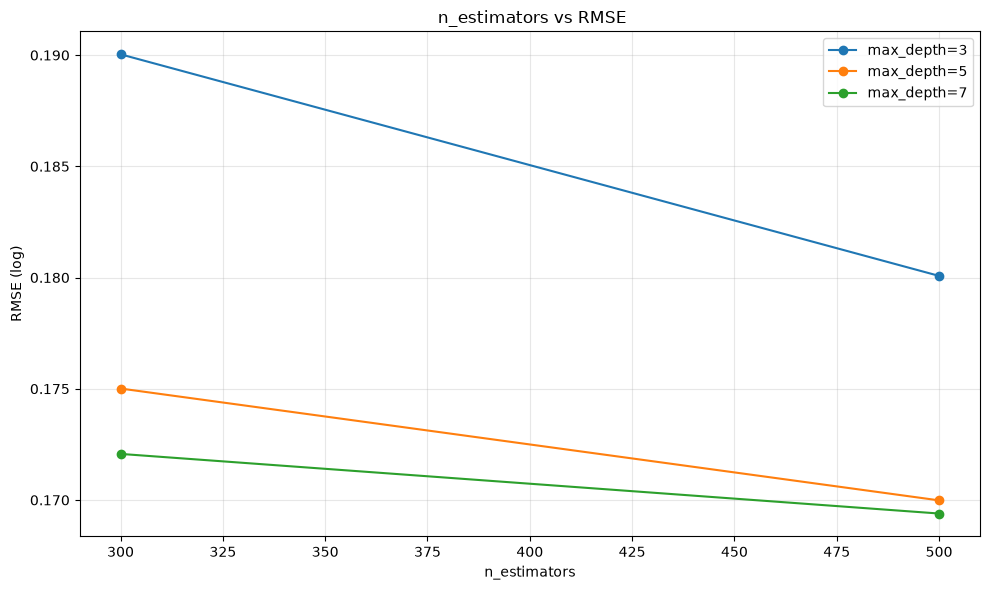

In [29]:
results = pd.DataFrame(grid.cv_results_)

results['rmse'] = -results['mean_test_score']
results.to_csv('gridsearch_results.csv', index=False)

plt.figure(figsize=(10, 6))

for depth in [3, 5, 7]:
    subset = results[results['param_max_depth'] == depth]
    subset = subset.groupby('param_n_estimators')['rmse'].mean()
    plt.plot(subset.index, subset.values, marker='o', label=f'max_depth={depth}')

plt.xlabel('n_estimators')
plt.ylabel('RMSE (log)')
plt.title(' n_estimators vs RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
xgb_best = grid.best_estimator_

y_pred_xgb_log = xgb_best.predict(x_val)

rmse_xgb_log = np.sqrt(mean_squared_error(y_val, y_pred_xgb_log))
r2_xgb_log = r2_score(y_val, y_pred_xgb_log)
print(f"XGBoost RMSE (log): {rmse_xgb_log:.4f}")
print(f"XGBoost R² (log): {r2_xgb_log:.4f}")

y_pred_xgb_price = np.expm1(y_pred_xgb_log)
y_val_price = np.expm1(y_val)
rmse_xgb_price = np.sqrt(mean_squared_error(y_val_price, y_pred_xgb_price))
print(f"XGBoost RMSE ($): {rmse_xgb_price:.2f}")

XGBoost RMSE (log): 0.1619
XGBoost R² (log): 0.9066
XGBoost RMSE ($): 113204.56


## 🧠. Model 3: CatBoost Regressor


In [23]:

cb = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=42,
    verbose=0
)

cb_param_grid = {
    'iterations': [300, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [3, 5, 7]
}

cb_grid = GridSearchCV(
    estimator=cb,
    param_grid=cb_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

cb_grid.fit(
    x_data_final,
    y_data_final,
    cat_features=['zipcode']
)


print("Best Parameters:", cb_grid.best_params_)
print(f"Best CV RMSE (log): {-cb_grid.best_score_:.4f}")

# Save model
joblib.dump(cb_grid, "catboost_best_model.pkl")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'depth': 6, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.1}
Best CV RMSE (log): 0.1627


['catboost_best_model.pkl']

In [24]:

cb_best = cb_grid.best_estimator_

y_pred_cb_log = cb_best.predict(x_val)

rmse_cb_log = np.sqrt(mean_squared_error(y_val, y_pred_cb_log))
r2_cb_log = r2_score(y_val, y_pred_cb_log)

print(f"CatBoost RMSE (log): {rmse_cb_log:.4f}")
print(f"CatBoost R² (log): {r2_cb_log:.4f}")

y_pred_cb_price = np.expm1(y_pred_cb_log)
y_val_price = np.expm1(y_val)

rmse_cb_price = np.sqrt(mean_squared_error(y_val_price, y_pred_cb_price))

print(f"CatBoost RMSE ($): {rmse_cb_price:.2f}")

CatBoost RMSE (log): 0.1599
CatBoost R² (log): 0.9089
CatBoost RMSE ($): 110589.76


# 📈 Model Comparison

---

In [25]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost","CatBoost"],
    "RMSE": [rmse_price, rmse_xgb_price,rmse_cb_price],
    "R²": [r2_log, r2_xgb_log,r2_cb_log]
})

comparison = comparison.sort_values("RMSE")
print(comparison)
comparison.to_csv("model_comparison.csv", index=False)

               Model           RMSE        R²
2           CatBoost  110589.758548  0.908906
1            XGBoost  113204.555247  0.906599
0  Linear Regression  189248.640648  0.777243


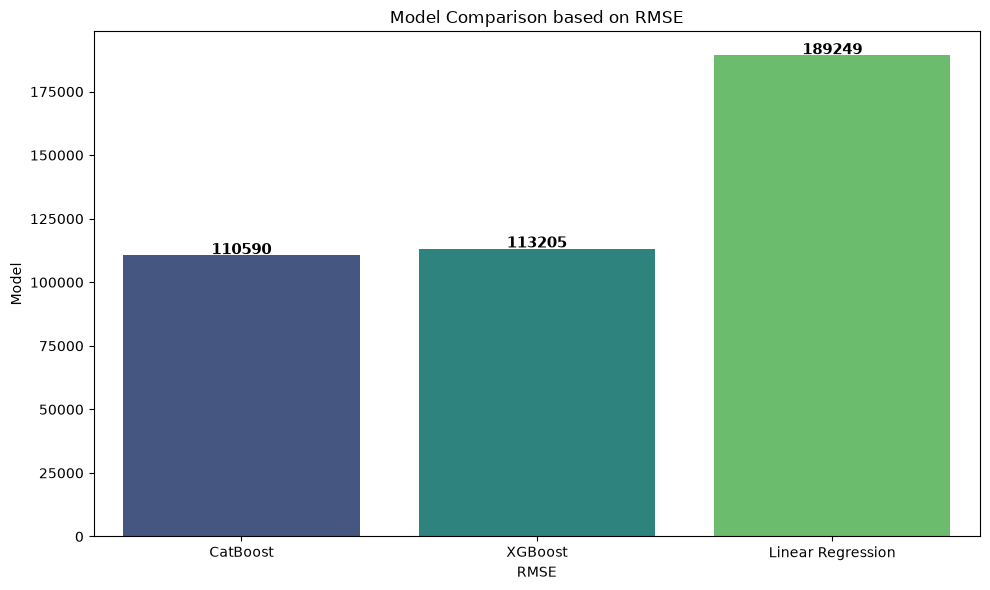

In [26]:
compairson_sorted = comparison.sort_values("RMSE")
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='RMSE', data=compairson_sorted, palette='viridis')
for i, v in enumerate(compairson_sorted["RMSE"]):
    plt.text(i, v + 500, f'{v:.0f}', ha='center', fontsize=11, fontweight='bold')
plt.title('Model Comparison based on RMSE')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

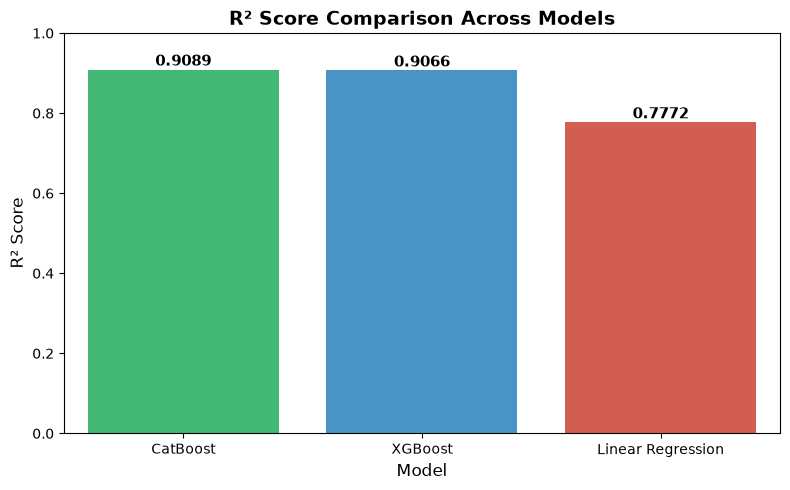

In [27]:
comparison_sorted_r2 = comparison.sort_values("R²", ascending=False)

plt.figure(figsize=(8,5))
colors = ['#2ecc71', '#3498db', '#e74c3c']
sns.barplot(x=comparison_sorted_r2["Model"], y=comparison_sorted_r2["R²"], palette=colors)
plt.title("R² Score Comparison Across Models", fontsize=14, fontweight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
for i, v in enumerate(comparison_sorted_r2["R²"]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()